# 🧠 Parkinson's Disease Detection
## Notebook 1: Exploratory Data Analysis (EDA)

**Goal:** Understand the dataset, check class distribution, and visualize patterns that separate healthy individuals from those with Parkinson's Disease.

**Dataset:** UCI Parkinson's Disease Dataset — 197 voice recordings, 24 features

In [15]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# Styling
plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette('Set2')
print('Libraries loaded successfully ✅')

Libraries loaded successfully ✅


## 2.2 Load and Inspect the Dataset

In [16]:
# Load the dataset
df = pd.read_csv('../data/parkinsons.csv')

# Basic overview
print('Shape:', df.shape)  # Should be (197, 24)
print('\nColumns:')
print(df.columns.tolist())
print('\nFirst 5 rows:')
df.head()

Shape: (195, 24)

Columns:
['name', 'MDVP:Fo(Hz)', 'MDVP:Fhi(Hz)', 'MDVP:Flo(Hz)', 'MDVP:Jitter(%)', 'MDVP:Jitter(Abs)', 'MDVP:RAP', 'MDVP:PPQ', 'Jitter:DDP', 'MDVP:Shimmer', 'MDVP:Shimmer(dB)', 'Shimmer:APQ3', 'Shimmer:APQ5', 'MDVP:APQ', 'Shimmer:DDA', 'NHR', 'HNR', 'status', 'RPDE', 'DFA', 'spread1', 'spread2', 'D2', 'PPE']

First 5 rows:


,name,MDVP:Fo(Hz),MDVP:Fhi(Hz),MDVP:Flo(Hz),MDVP:Jitter(%),MDVP:Jitter(Abs),MDVP:RAP,MDVP:PPQ,Jitter:DDP,MDVP:Shimmer,...,Shimmer:DDA,NHR,HNR,status,RPDE,DFA,spread1,spread2,D2,PPE
0,phon_R01_S01_1,119.992,157.302,74.997,0.00784,0.00007,0.00370,0.00554,0.01109,0.04374,...,0.06545,0.02211,21.033,1,0.414783,0.815285,-4.813031,0.266482,2.301442,0.284654
1,phon_R01_S01_2,122.400,148.650,113.819,0.00968,0.00008,0.00465,0.00696,0.01394,0.06134,...,0.09403,0.01929,19.085,1,0.458359,0.819521,-4.075192,0.335590,2.486855,0.368674
2,phon_R01_S01_3,116.682,131.111,111.555,0.01050,0.00009,0.00544,0.00781,0.01633,0.05233,...,0.08270,0.01309,20.651,1,0.429895,0.825288,-4.443179,0.311173,2.342259,0.332634
3,phon_R01_S01_4,116.676,137.871,111.366,0.00997,0.00009,0.00502,0.00698,0.01505,0.05492,...,0.08771,0.01353,20.644,1,0.434969,0.819235,-4.117501,0.334147,2.405554,0.368975
4,phon_R01_S01_5,116.014,141.781,110.655,0.01284,0.00011,0.00655,0.00908,0.01966,0.06425,...,0.10470,0.01767,19.649,1,0.417356,0.823484,-3.747787,0.234513,2.332180,0.410335


In [17]:
# Data types and missing values
print('Data Types & Missing Values:')
print(df.dtypes)
print('\nNull values per column:')
print(df.isnull().sum())
print('\n✅ No missing values — this is a clean dataset!')

Data Types & Missing Values:
name                 object
MDVP:Fo(Hz)         float64
MDVP:Fhi(Hz)        float64
MDVP:Flo(Hz)        float64
MDVP:Jitter(%)      float64
MDVP:Jitter(Abs)    float64
MDVP:RAP            float64
MDVP:PPQ            float64
Jitter:DDP          float64
MDVP:Shimmer        float64
MDVP:Shimmer(dB)    float64
Shimmer:APQ3        float64
Shimmer:APQ5        float64
MDVP:APQ            float64
Shimmer:DDA         float64
NHR                 float64
HNR                 float64
status                int64
RPDE                float64
DFA                 float64
spread1             float64
spread2             float64
D2                  float64
PPE                 float64
dtype: object

Null values per column:
name                0
MDVP:Fo(Hz)         0
MDVP:Fhi(Hz)        0
MDVP:Flo(Hz)        0
MDVP:Jitter(%)      0
MDVP:Jitter(Abs)    0
MDVP:RAP            0
MDVP:PPQ            0
Jitter:DDP          0
MDVP:Shimmer        0
MDVP:Shimmer(dB)    0
Shimmer:APQ3      

In [18]:
# Statistical summary
df.describe().T

,count,mean,std,min,25%,50%,75%,max
MDVP:Fo(Hz),195.0,154.228641,41.390065,88.333000,117.572000,148.790000,182.769000,260.105000
MDVP:Fhi(Hz),195.0,197.104918,91.491548,102.145000,134.862500,175.829000,224.205500,592.030000
MDVP:Flo(Hz),195.0,116.324631,43.521413,65.476000,84.291000,104.315000,140.018500,239.170000
MDVP:Jitter(%),195.0,0.006220,0.004848,0.001680,0.003460,0.004940,0.007365,0.033160
MDVP:Jitter(Abs),195.0,0.000044,0.000035,0.000007,0.000020,0.000030,0.000060,0.000260
MDVP:RAP,195.0,0.003306,0.002968,0.000680,0.001660,0.002500,0.003835,0.021440
MDVP:PPQ,195.0,0.003446,0.002759,0.000920,0.001860,0.002690,0.003955,0.019580
Jitter:DDP,195.0,0.009920,0.008903,0.002040,0.004985,0.007490,0.011505,0.064330
MDVP:Shimmer,195.0,0.029709,0.018857,0.009540,0.016505,0.022970,0.037885,0.119080
MDVP:Shimmer(dB),195.0,0.282251,0.194877,0.085000,0.148500,0.221000,0.350000,1.302000


## 2.3 Check Class Distribution

Class Distribution:
status
1    147
0     48
Name: count, dtype: int64

Parkinson's: 147 patients
Healthy:     48 patients

Imbalance Ratio: 3.1:1


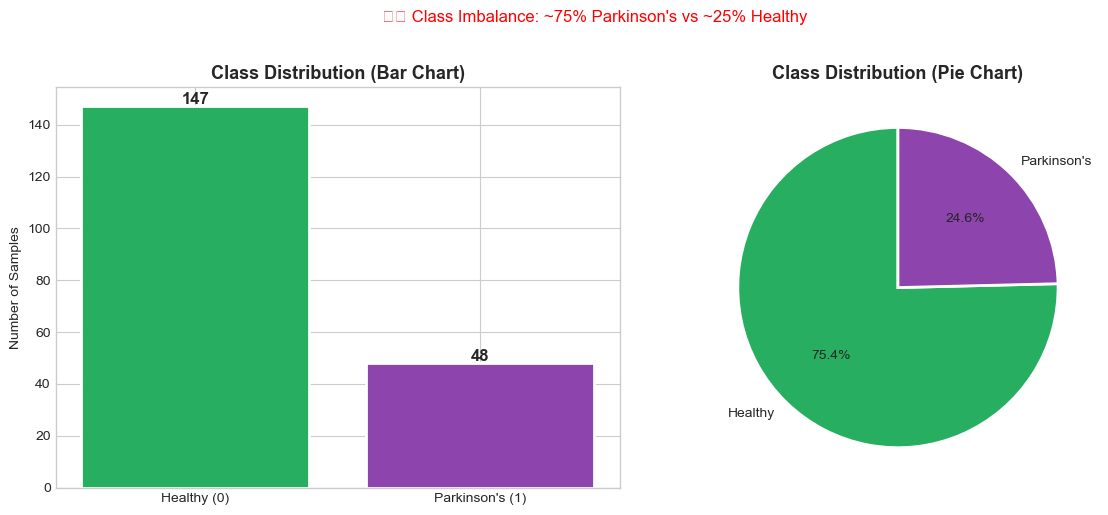


⚠️ Note: Class imbalance exists — accuracy alone is misleading!


In [19]:
# Class distribution
print('Class Distribution:')
print(df['status'].value_counts())
print()
print(f"Parkinson's: {df['status'].sum()} patients")
print(f"Healthy:     {(df['status']==0).sum()} patients")
print(f"\nImbalance Ratio: {df['status'].sum()/(df['status']==0).sum():.1f}:1")

# Plot class distribution
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Bar chart
counts = df['status'].value_counts()
axes[0].bar(['Healthy (0)', "Parkinson's (1)"], counts.values,
            color=['#27AE60', '#8E44AD'], edgecolor='white', linewidth=2)
axes[0].set_title('Class Distribution (Bar Chart)', fontsize=13, fontweight='bold')
axes[0].set_ylabel('Number of Samples')
for i, v in enumerate(counts.values):
    axes[0].text(i, v + 1, str(v), ha='center', fontweight='bold', fontsize=12)

# Pie chart
axes[1].pie(counts.values, labels=["Healthy", "Parkinson's"],
            colors=['#27AE60', '#8E44AD'], autopct='%1.1f%%',
            startangle=90, wedgeprops={'edgecolor': 'white', 'linewidth': 2})
axes[1].set_title('Class Distribution (Pie Chart)', fontsize=13, fontweight='bold')

plt.suptitle('⚠️ Class Imbalance: ~75% Parkinson\'s vs ~25% Healthy', 
             fontsize=12, color='red', y=1.02)
plt.tight_layout()
plt.savefig('../results/class_distribution.png', dpi=150, bbox_inches='tight')
plt.show()
print('\n⚠️ Note: Class imbalance exists — accuracy alone is misleading!')

## 3.1 Distribution of Key Features

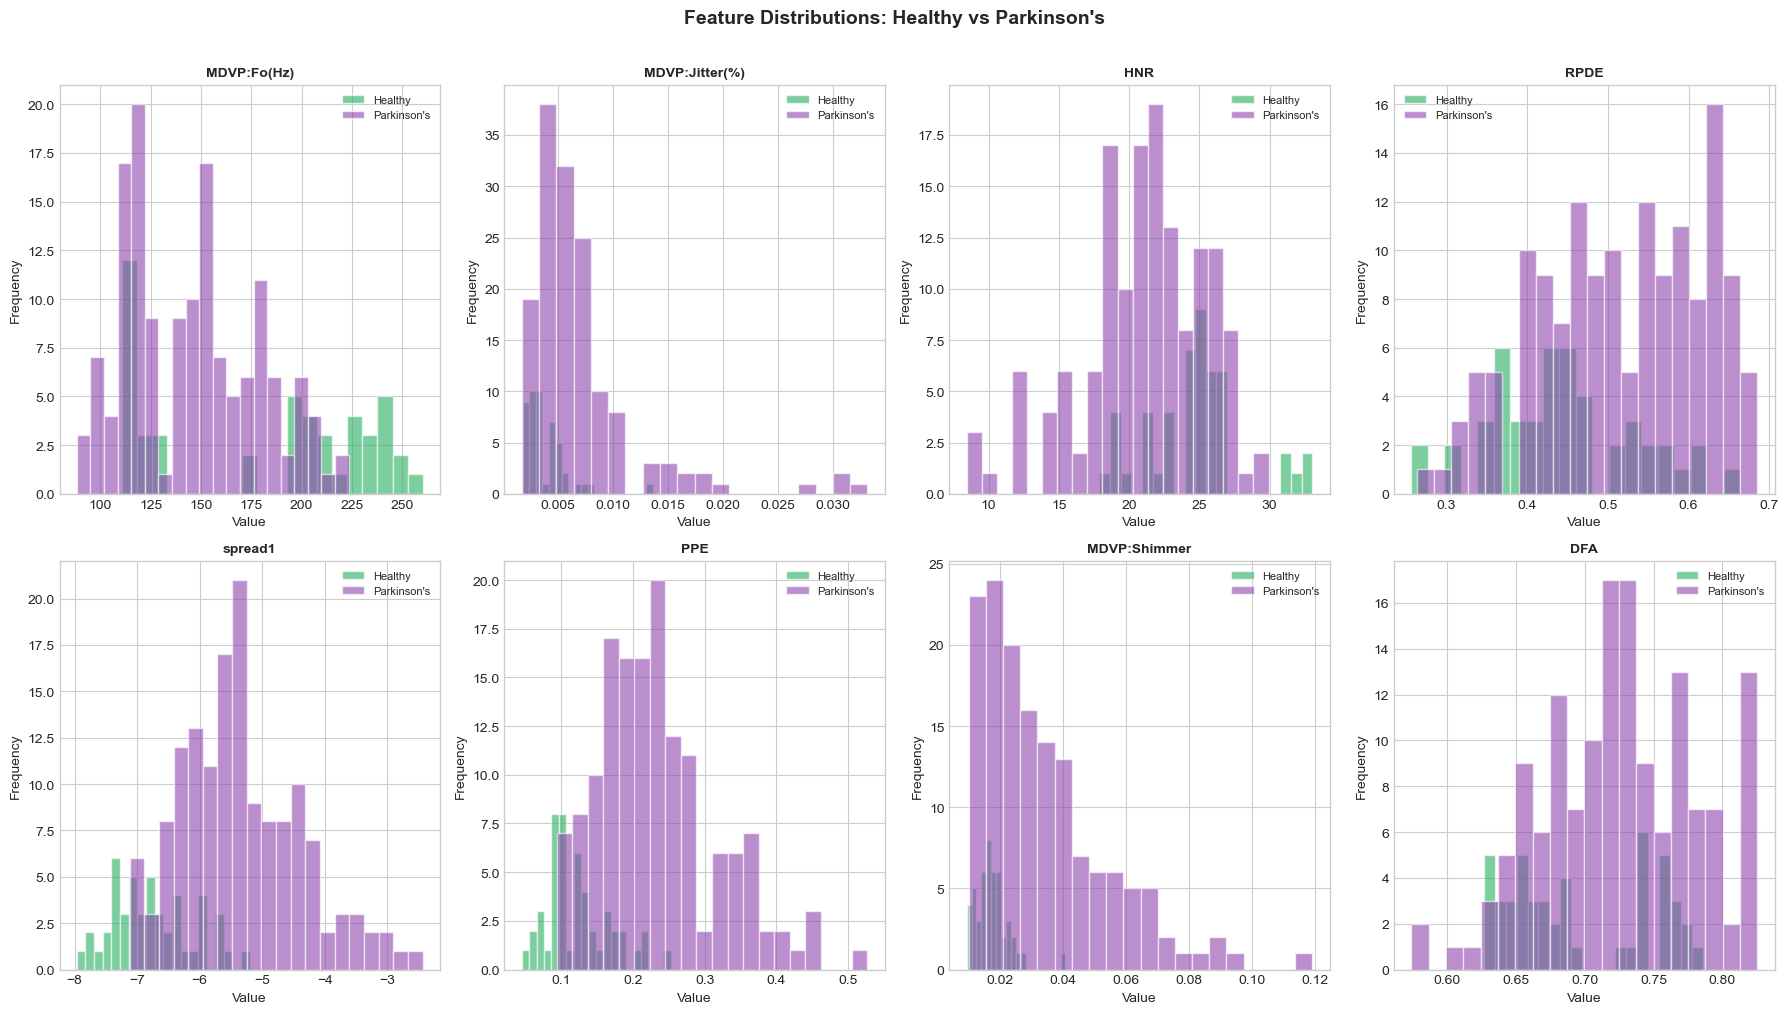

In [20]:
# Plot distributions for key features — comparing Healthy vs Parkinson's
key_features = ['MDVP:Fo(Hz)', 'MDVP:Jitter(%)', 'HNR', 'RPDE', 
                'spread1', 'PPE', 'MDVP:Shimmer', 'DFA']

fig, axes = plt.subplots(2, 4, figsize=(18, 10))

for idx, feature in enumerate(key_features):
    ax = axes[idx // 4, idx % 4]
    for status, label, color in [(0, 'Healthy', '#27AE60'), (1, "Parkinson's", '#8E44AD')]:
        subset = df[df['status'] == status][feature]
        ax.hist(subset, alpha=0.6, label=label, color=color, bins=20, edgecolor='white')
    ax.set_title(feature, fontsize=10, fontweight='bold')
    ax.legend(fontsize=8)
    ax.set_xlabel('Value')
    ax.set_ylabel('Frequency')

plt.suptitle('Feature Distributions: Healthy vs Parkinson\'s', 
             fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('../results/feature_distributions.png', dpi=150, bbox_inches='tight')
plt.show()

## 3.2 Correlation Heatmap

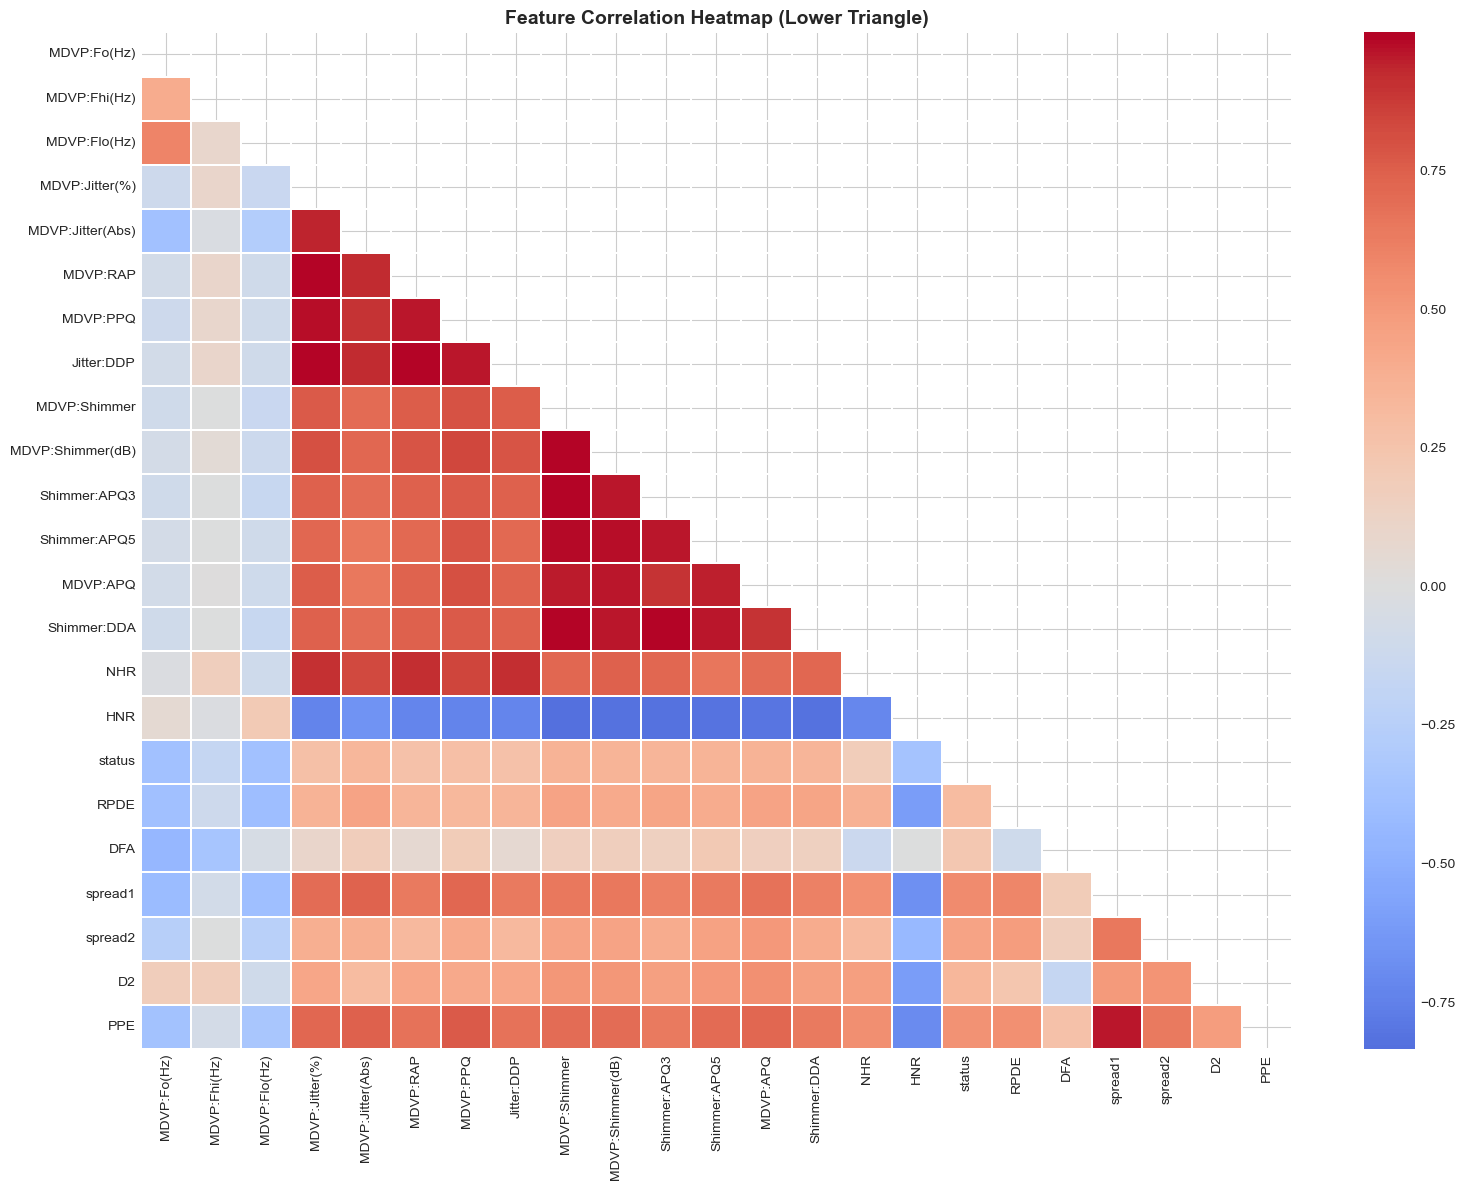

Top 10 features correlated with Parkinson's status:
status              1.000000
spread1             0.564838
PPE                 0.531039
spread2             0.454842
MDVP:Fo(Hz)         0.383535
MDVP:Flo(Hz)        0.380200
MDVP:Shimmer        0.367430
MDVP:APQ            0.364316
HNR                 0.361515
Shimmer:APQ5        0.351148
MDVP:Shimmer(dB)    0.350697
Name: status, dtype: float64


In [21]:
# Select numeric columns only
numeric_df = df.drop(columns=['name'])  # 'name' is a string ID column

plt.figure(figsize=(16, 12))
mask = np.triu(np.ones_like(numeric_df.corr(), dtype=bool))
sns.heatmap(numeric_df.corr(), annot=False,
            cmap='coolwarm', center=0,
            linewidths=0.3, mask=mask)
plt.title('Feature Correlation Heatmap (Lower Triangle)', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('../results/correlation_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()

# Find features most correlated with target
corr_with_target = numeric_df.corr()['status'].abs().sort_values(ascending=False)
print('Top 10 features correlated with Parkinson\'s status:')
print(corr_with_target.head(11))  # 11 because first is 'status' itself

## 3.3 Boxplots by Class

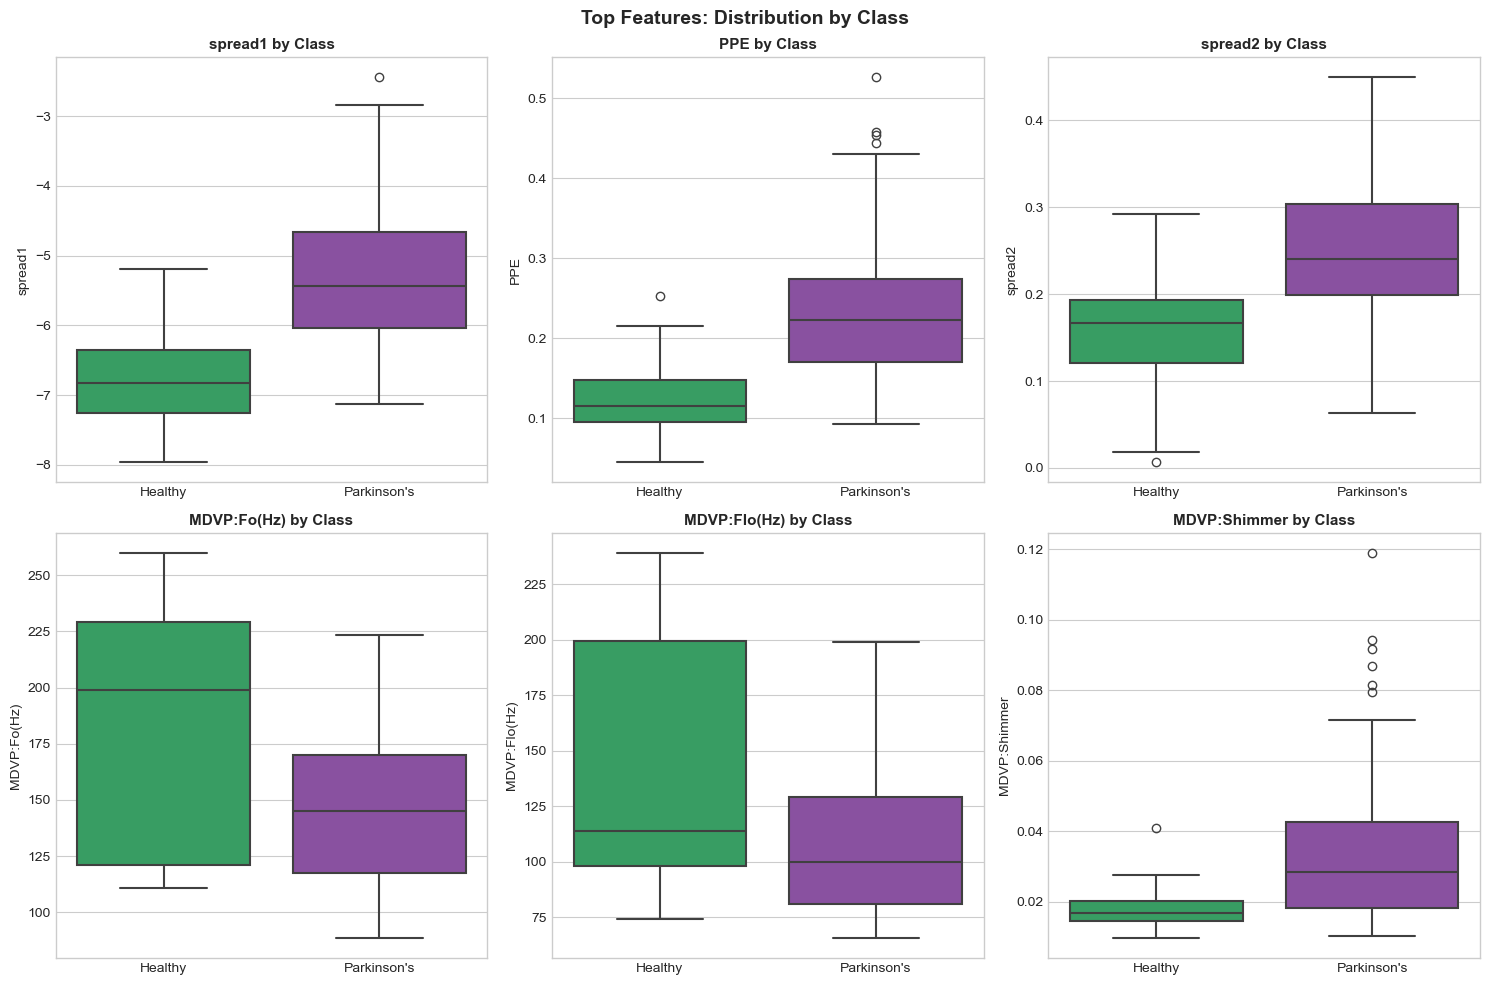

In [22]:
# Boxplots for top correlated features
df['status'] = pd.to_numeric(df['status'])

top_features = corr_with_target.drop('status').head(6).index.tolist()

fig, axes = plt.subplots(2, 3, figsize=(15, 10))

for idx, feature in enumerate(top_features):
    ax = axes[idx // 3, idx % 3]

    sns.boxplot(
        x='status',
        y=feature,
        data=df,
        palette=['#27AE60', '#8E44AD'],
        ax=ax,
        linewidth=1.5
    )

    ax.set_xticks([0, 1])
    ax.set_xticklabels(['Healthy', "Parkinson's"])
    ax.set_title(f'{feature} by Class', fontsize=11, fontweight='bold')
    ax.set_xlabel('')

plt.suptitle('Top Features: Distribution by Class', fontsize=14, fontweight='bold')

plt.tight_layout()
plt.show()

## 3.4 Pairplot of Top Features

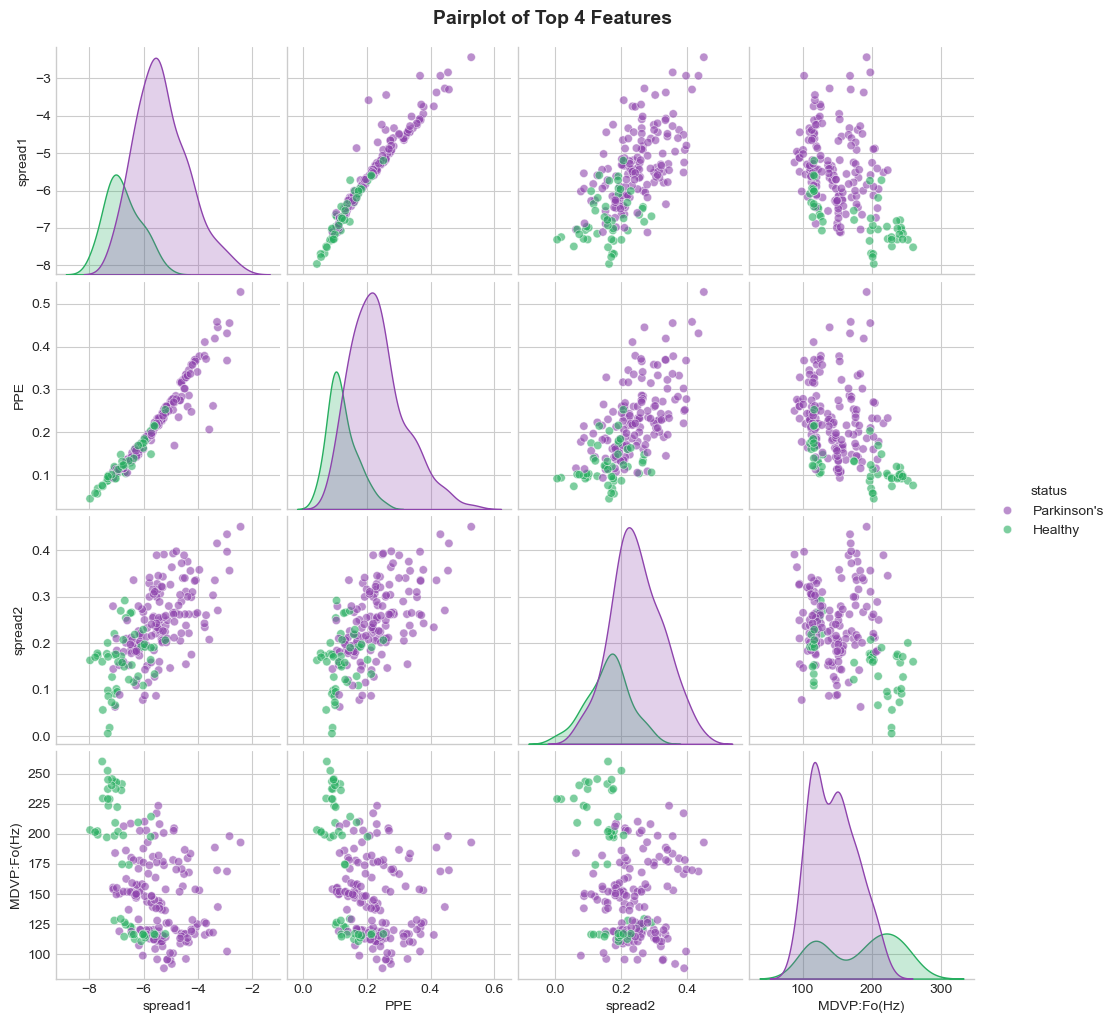


✅ EDA Complete! Key observations:
  - spread1, PPE, RPDE, and DFA show strong separation between classes
  - MDVP:Fo(Hz) shows some overlap — less discriminative alone
  - Class imbalance (~75% PD) requires careful evaluation with recall


In [23]:
# Pairplot for top 4 most correlated features
top4 = corr_with_target.drop('status').head(4).index.tolist()
pairplot_df = df[top4 + ['status']].copy()
pairplot_df['status'] = pairplot_df['status'].map({0: 'Healthy', 1: "Parkinson's"})

g = sns.pairplot(pairplot_df, hue='status', 
                  palette={'Healthy': '#27AE60', "Parkinson's": '#8E44AD'},
                  diag_kind='kde', plot_kws={'alpha': 0.6})
g.fig.suptitle('Pairplot of Top 4 Features', y=1.02, fontsize=14, fontweight='bold')
plt.savefig('../results/pairplot.png', dpi=100, bbox_inches='tight')
plt.show()
print('\n✅ EDA Complete! Key observations:')
print('  - spread1, PPE, RPDE, and DFA show strong separation between classes')
print('  - MDVP:Fo(Hz) shows some overlap — less discriminative alone')
print('  - Class imbalance (~75% PD) requires careful evaluation with recall')